Using device: cuda
GPU: NVIDIA GeForce RTX 5080
正在生成覆盖双移线边界条件的多场景数据...
X shape: (400, 200, 6)
X_changed shape: (400, 200, 6)
U shape: (400, 199, 2)
离线数据已保存。


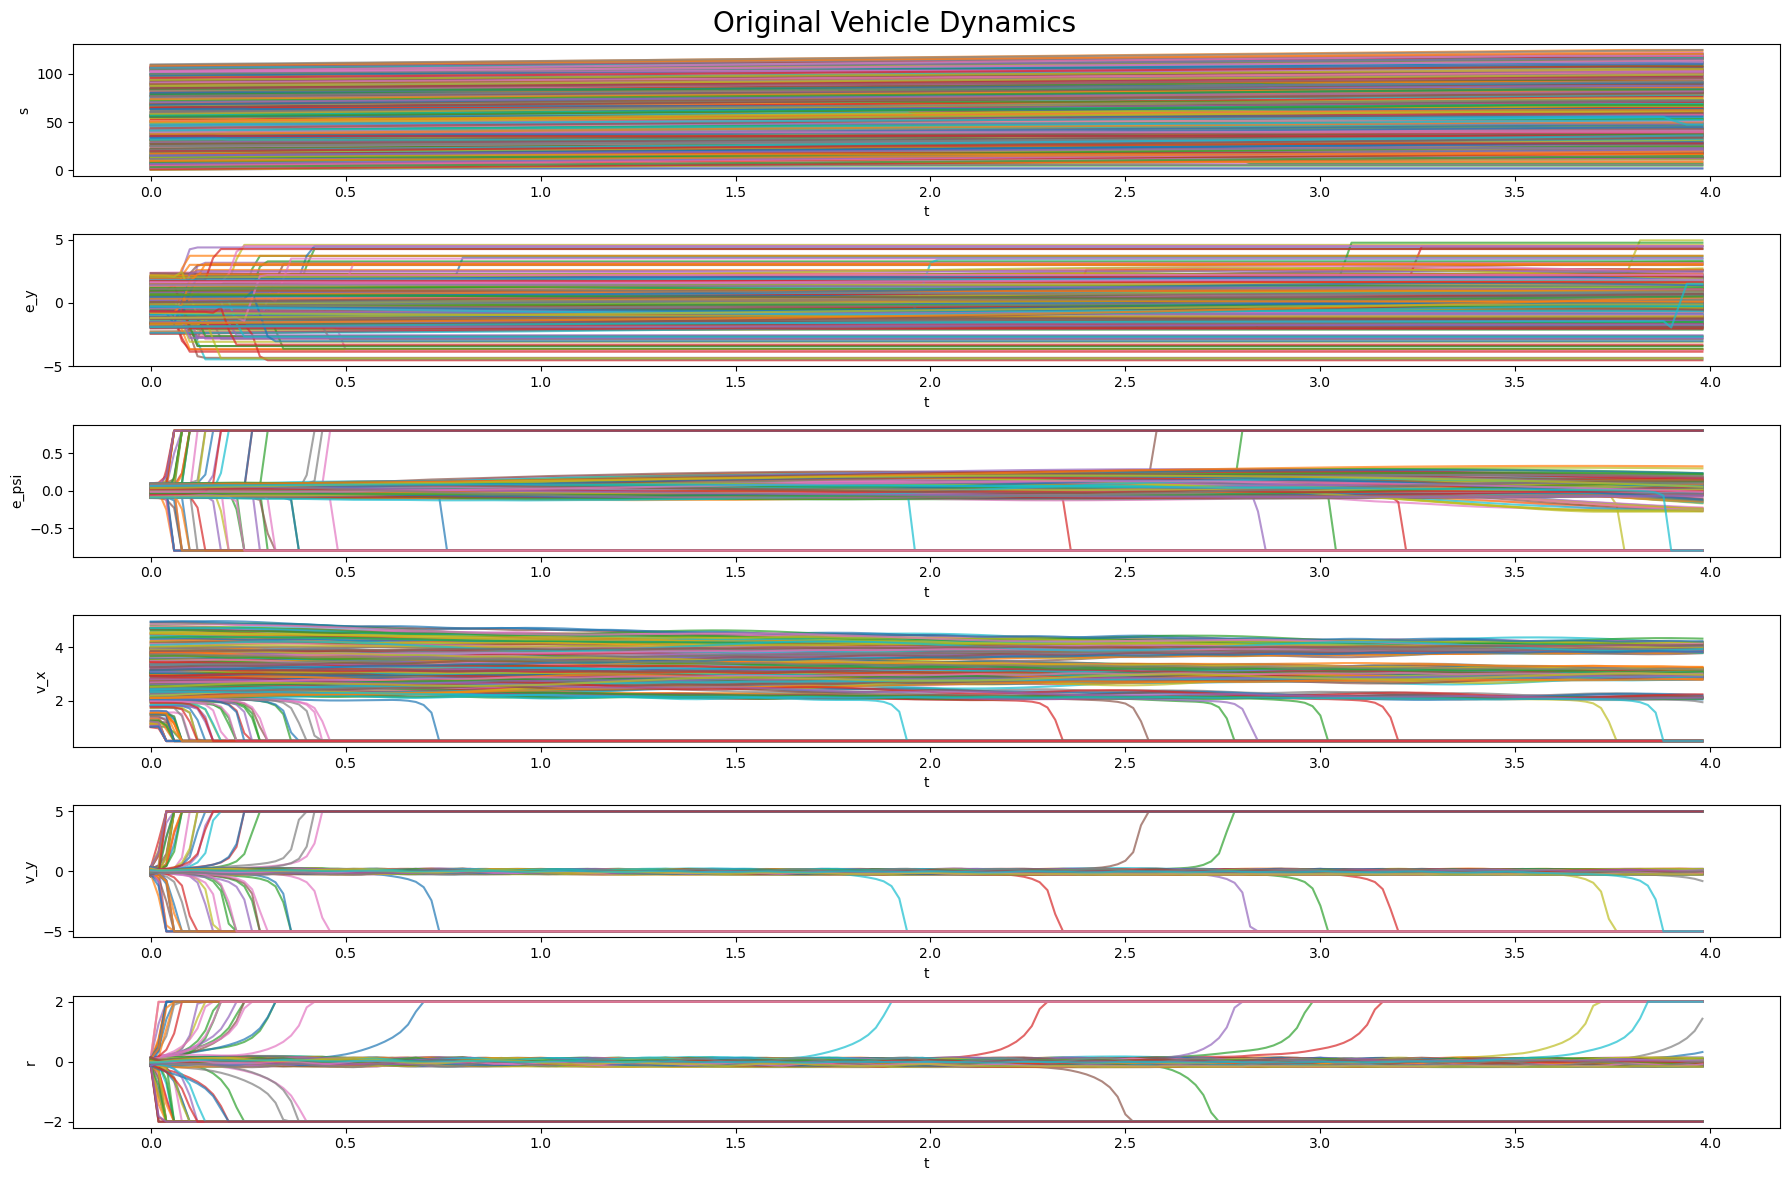

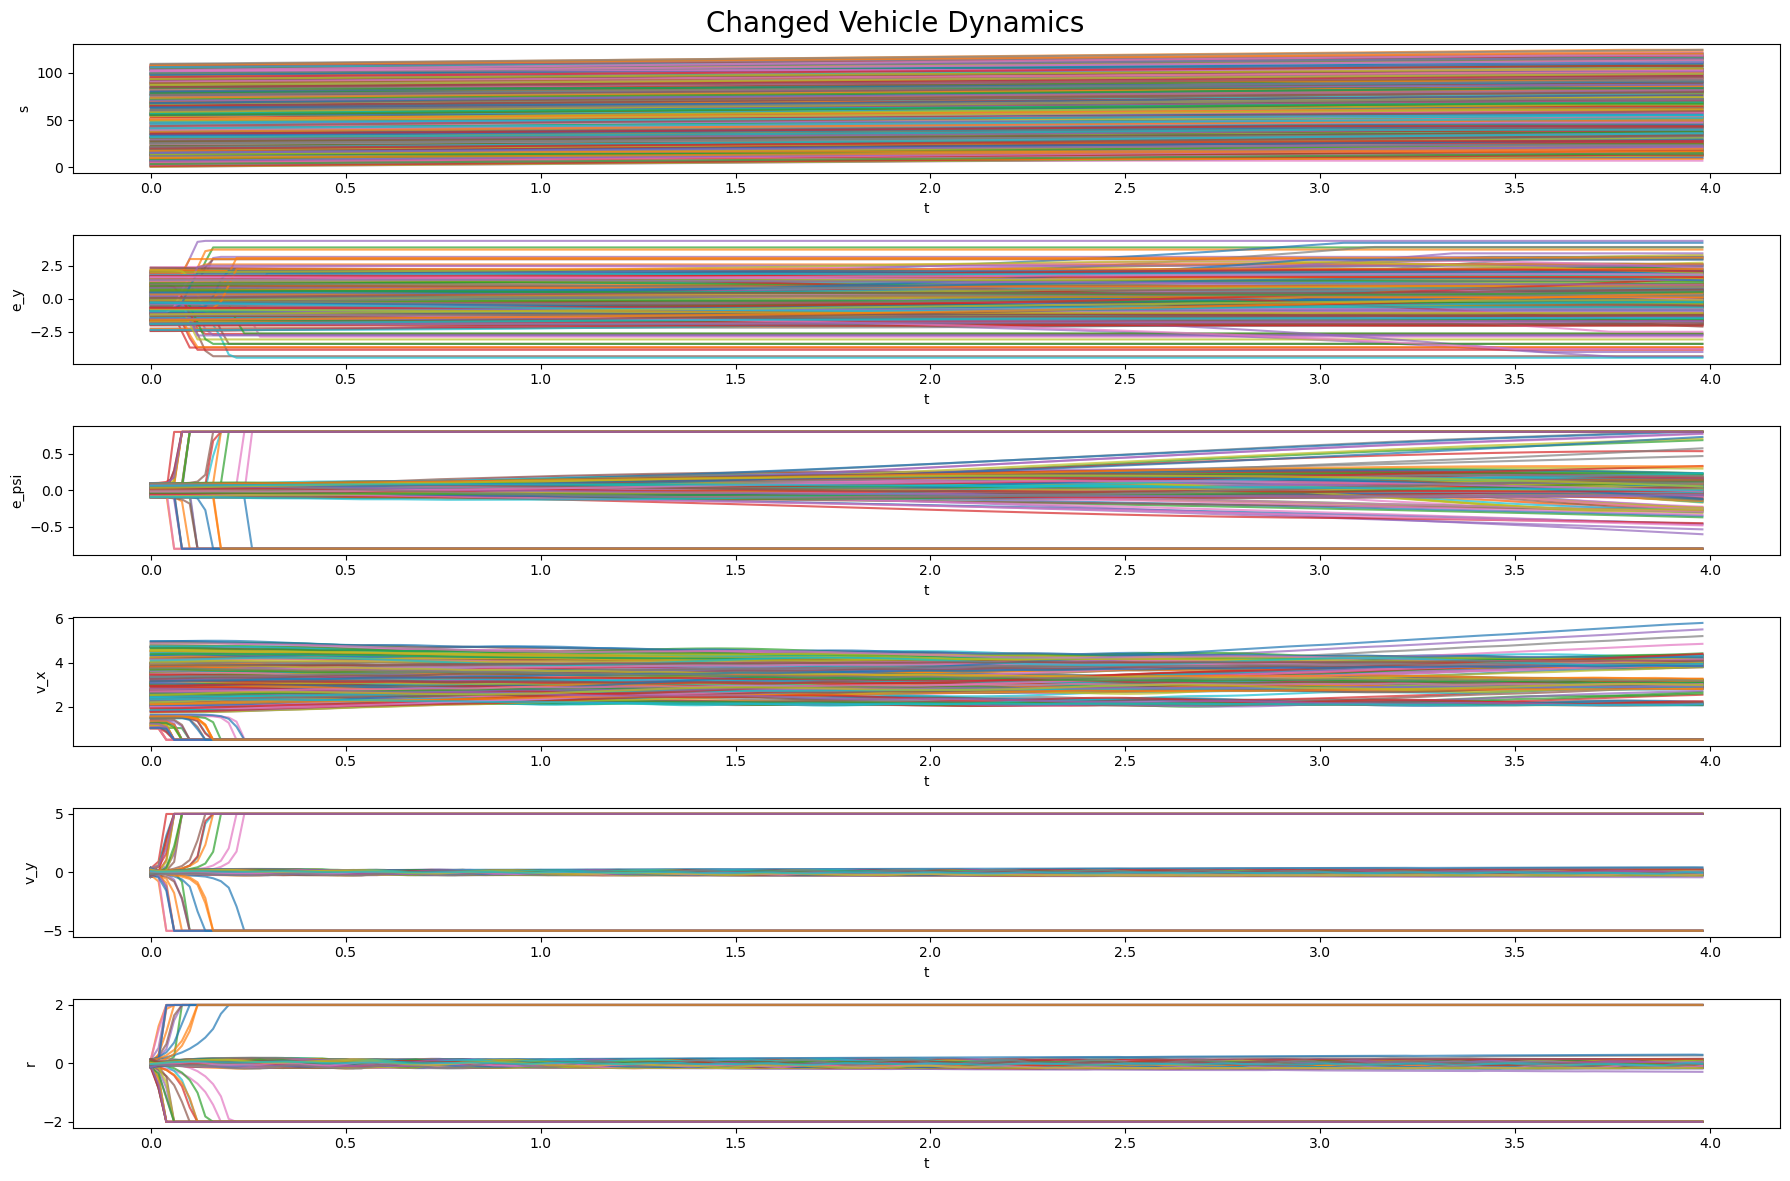

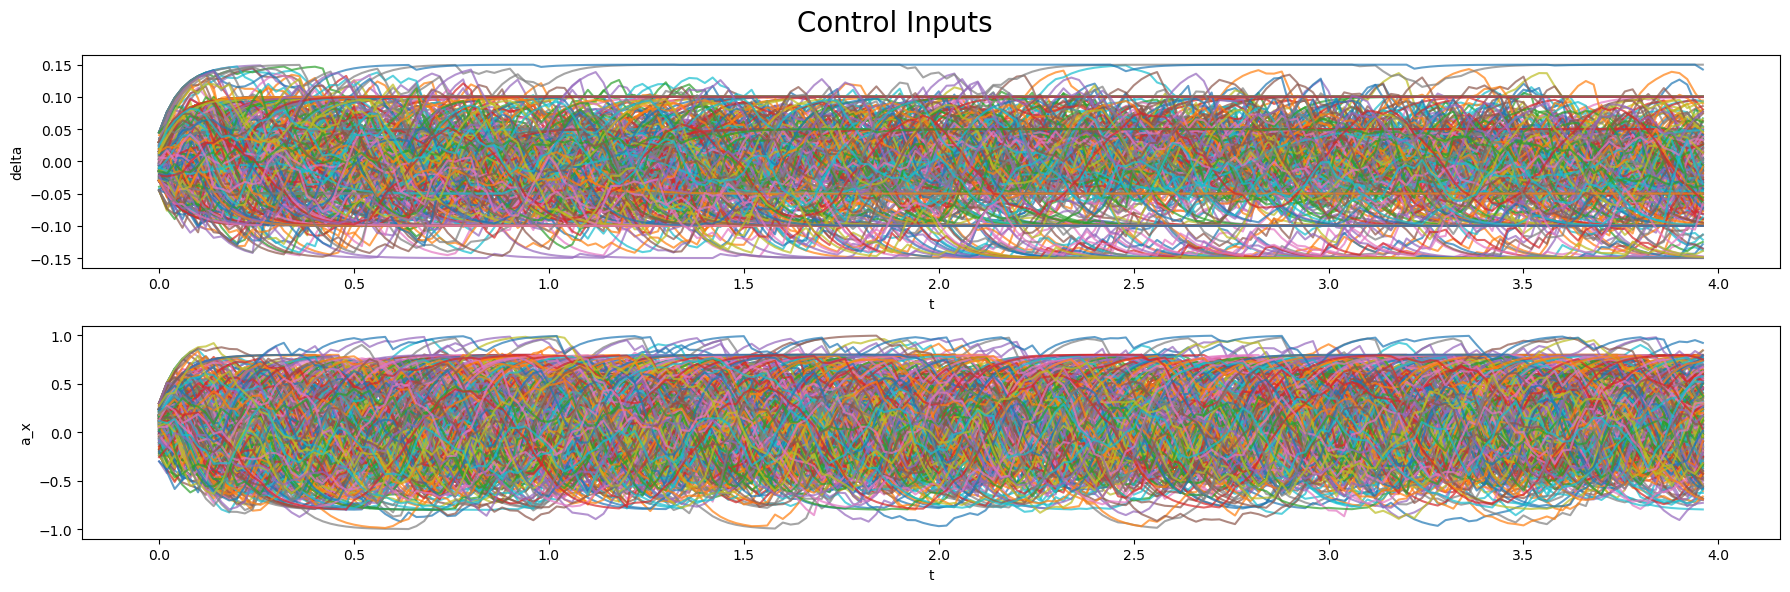

Model save path: saved_models/single_vehicle/linear/Koop_vehicle_Dim24_dt_0.02.pth
Epoch   1: train loss: 1.3662568364, validation loss: 2.0008560631
Epoch   2: train loss: 1.1965412934, validation loss: 1.9207477782
Epoch   3: train loss: 1.1456107851, validation loss: 1.8732831499
Epoch   4: train loss: 1.1106558744, validation loss: 1.8368863546
Epoch   5: train loss: 1.0837022379, validation loss: 1.8121991653
Epoch   6: train loss: 1.0626682592, validation loss: 1.7902509110
Epoch   7: train loss: 1.0466816018, validation loss: 1.7683409105
Epoch   8: train loss: 1.0292592914, validation loss: 1.7496365292
Epoch   9: train loss: 1.0156466207, validation loss: 1.7314071662
Epoch  10: train loss: 1.0005290141, validation loss: 1.7156755456
Epoch  11: train loss: 0.9881183302, validation loss: 1.7003961049
Epoch  12: train loss: 0.9766824556, validation loss: 1.6863745966
Epoch  13: train loss: 0.9659606641, validation loss: 1.6719592497
Epoch  14: train loss: 0.9559768748, validatio

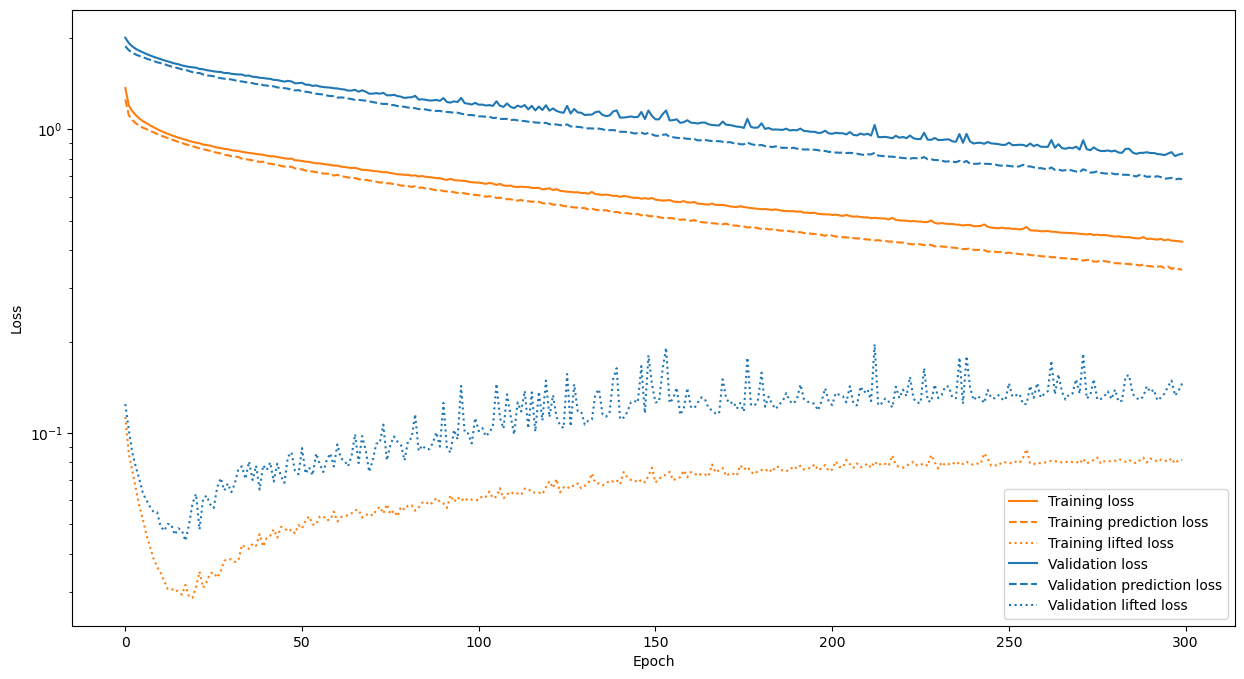

In [1]:
# import libraries
import math
import os
import pickle
import random
import time
import itertools
import importlib

# import numpy
import numpy as np
import matplotlib.pyplot as plt
import sklearn.preprocessing
from sklearn import preprocessing

import torch
import scipy
import scipy.io

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", DEVICE)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# import Koopman Libraries
from core.koopman_core_linear import KoopDNN_linear, KoopmanNet_linear, KoopmanNetCtrl_linear
from core.util import fit_standardizer
from models.koop_model import model_matricies, lift_raw, lift_scaled

# ===== import Frenet-real-state dynamics file =====
import dynamics.cacaNEWlv2 as cacaNEWlv2

importlib.reload(cacaNEWlv2)
from dynamics.cacaNEWlv2 import FK_solver, single_vehicle_data_gen_multi

# control
from control_files.nmpc_osqp_adapt import NonlinearMPCController
from dynamics.learned_models_control.linear_dynamics import linear_Dynamics


# ===== helper for Frenet path =====
def build_test_frenet_path_from_xy(x_ref_path, y_ref_path):
    dx_seg = np.diff(x_ref_path)
    dy_seg = np.diff(y_ref_path)
    ds_seg = np.sqrt(dx_seg ** 2 + dy_seg ** 2)
    s_ref = np.concatenate(([0.0], np.cumsum(ds_seg)))

    dx = np.gradient(x_ref_path)
    dy = np.gradient(y_ref_path)
    psi_ref = np.unwrap(np.arctan2(dy, dx))

    ds = np.gradient(s_ref)
    curvature_ref = np.gradient(psi_ref) / np.maximum(ds, 1e-8)
    curvature_ref = np.nan_to_num(curvature_ref)

    return s_ref, psi_ref, curvature_ref


# ===== Frenet -> Cartesian for plotting =====
def frenet_to_global(s_arr, ey_arr, s_ref_path, x_ref_path, y_ref_path, psi_ref_path):
    x_center = np.interp(s_arr, s_ref_path, x_ref_path)
    y_center = np.interp(s_arr, s_ref_path, y_ref_path)
    psi_center = np.interp(s_arr, s_ref_path, psi_ref_path)

    x_global = x_center - ey_arr * np.sin(psi_center)
    y_global = y_center + ey_arr * np.cos(psi_center)
    return x_global, y_global


def to_numpy(x):
    if hasattr(x, "detach"):
        return x.detach().cpu().numpy()
    return np.array(x)


def scale_state(x_raw, standardizer_x):
    return standardizer_x.transform(np.asarray(x_raw).reshape(1, -1)).flatten()


def scale_state_batch(X_raw, standardizer_x):
    return standardizer_x.transform(np.asarray(X_raw))


def decode_scaled_to_raw(x_scaled, standardizer_x):
    return standardizer_x.inverse_transform(np.asarray(x_scaled).reshape(1, -1)).flatten()


# =============================================================================
# 系统拟合
# =============================================================================
linear = True

# =============================================================================
# 数据生成 (针对 100m 双移线优化：丰富场景 + 物理不变性数据增强)
# =============================================================================
sys_pars_base = {}

# 6 states: x=[s, e_y, e_psi, v_x, v_y, r]
num_states = 6
num_inputs = 2
dt = 0.02

sys_pars_base["num_states"] = num_states
sys_pars_base["num_inputs"] = num_inputs
sys_pars_base["dt"] = dt

# nominal vehicle parameters
sys_pars_base["m"] = 1500.0
sys_pars_base["Iz"] = 2250.0
sys_pars_base["lf"] = 1.2
sys_pars_base["lr"] = 1.6
sys_pars_base["Cf"] = 80000.0
sys_pars_base["Cr"] = 80000.0
sys_pars_base["curvature_ref"] = 0.0
sys_pars_base["uncertainty"] = "NA"
sys_pars_base["amp"] = 0.0

# changed vehicle parameters
sys_pars_new_base = dict(sys_pars_base)
sys_pars_new_base["m"] = 1650.0
sys_pars_new_base["Iz"] = 2400.0
sys_pars_new_base["Cf"] = 70000.0
sys_pars_new_base["Cr"] = 70000.0

sensor_noise = False
SNR_DB = 30
num_snaps = 200

# 1. 构建混合数据集配置，激发出不同强度的纵横向耦合动态
configs = [
    {"vx_ref": 3.0, "delta_max": 0.05, "ax_max": 0.6, "freq": 1.0},
    {"vx_ref": 3.0, "delta_max": 0.15, "ax_max": 1.0, "freq": 0.5},  # 低频大转角，逼近 DLC
    {"vx_ref": 3.0, "delta_max": 0.10, "ax_max": 0.8, "freq": 0.2},  # 更低频，拉大 e_y 侧移
    {"vx_ref": 4.0, "delta_max": 0.10, "ax_max": 0.8, "freq": 0.5},  # 高速覆盖
    {"vx_ref": 2.0, "delta_max": 0.10, "ax_max": 0.8, "freq": 0.5},  # 低速覆盖
]

num_traj_per_batch = 80
X_list, X_changed_list, U_list = [], [], []

print("正在生成覆盖双移线边界条件的多场景数据...")
for cfg in configs:
    sp = dict(sys_pars_base)
    sp.update(cfg)
    sp["U_type"] = "sinusoidal"

    sp_new = dict(sys_pars_new_base)
    sp_new.update(cfg)
    sp_new["U_type"] = "sinusoidal"

    X_b, X_changed_b, U_b = single_vehicle_data_gen_multi(
        num_traj_per_batch, num_snaps, sp, sp_new, sensor_noise, SNR_DB
    )
    X_list.append(X_b)
    X_changed_list.append(X_changed_b)
    U_list.append(U_b)

X = np.concatenate(X_list, axis=0)
X_changed = np.concatenate(X_changed_list, axis=0)
U = np.concatenate(U_list, axis=0)
num_traj = X.shape[0]  # Total 400

# 2. 【核心】数据增强 (Data Augmentation)
# 因为在直道上 (curvature_ref=0) 车辆的动态方程不受绝对纵向距离 s 和横向偏移 e_y 的影响
# 所以我们可以直接随机平移 s 和 e_y，扩大 Standardizer 的分布覆盖面，彻底解决饱和越界问题！
np.random.seed(42)
for i in range(num_traj):
    s_shift = np.random.uniform(0.0, 110.0)  # 覆盖 DLC 的 100m 长度
    ey_shift = np.random.uniform(-2.0, 2.0)  # 覆盖 DLC 的侧向偏差并留出充足泛化裕度

    X[i, :, 0] += s_shift
    X_changed[i, :, 0] += s_shift
    X[i, :, 1] += ey_shift
    X_changed[i, :, 1] += ey_shift

# 打乱数据以防止验证集切分时分布不均
indices = np.random.permutation(num_traj)
X = X[indices]
X_changed = X_changed[indices]
U = U[indices]

num_train = int(0.8 * num_traj)
num_val = num_traj - num_train

# 恢复默认的 sys_pars 用于后续代码流转基准
sys_pars = dict(sys_pars_base)
sys_pars.update({"vx_ref": 3.0, "delta_max": 0.05, "ax_max": 0.6, "freq": 1.0, "U_type": "sinusoidal"})
sys_pars_new = dict(sys_pars_new_base)
sys_pars_new.update({"vx_ref": 3.0, "delta_max": 0.05, "ax_max": 0.6, "freq": 1.0, "U_type": "sinusoidal"})

print("X shape:", X.shape)
print("X_changed shape:", X_changed.shape)
print("U shape:", U.shape)

os.makedirs("saved_data/single_vehicle", exist_ok=True)

np.savez_compressed(
    "saved_data/single_vehicle/offline_dataset.npz",
    X=X,
    X_changed=X_changed,
    U=U
)

with open("saved_data/single_vehicle/offline_dataset_pars.pkl", "wb") as f:
    pickle.dump({
        "sys_pars": sys_pars,
        "sys_pars_new": sys_pars_new,
        "num_traj": num_traj,
        "num_train": num_train,
        "num_val": num_val,
        "num_snaps": num_snaps,
        "sensor_noise": sensor_noise,
        "SNR_DB": SNR_DB
    }, f)

print("离线数据已保存。")

state_labels = ["s", "e_y", "e_psi", "v_x", "v_y", "r"]
input_labels = ["delta", "a_x"]
t_train = np.linspace(0, dt * (num_snaps - 1), num_snaps)

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Original Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 12))
for j in range(num_traj):
    for i in range(num_states):
        plt.subplot(num_states, 1, i + 1)
        plt.plot(t_train, X_changed[j, :, i], alpha=0.7)
        plt.ylabel(state_labels[i])
        plt.xlabel("t")
plt.suptitle("Changed Vehicle Dynamics", fontsize=20)
plt.tight_layout()
plt.show()

plt.figure(figsize=(18, 6))
for j in range(num_traj):
    for i in range(num_inputs):
        plt.subplot(num_inputs, 1, i + 1)
        plt.plot(t_train[:-1], U[j, :, i], alpha=0.7)
        plt.ylabel(input_labels[i])
        plt.xlabel("t")
plt.suptitle("Control Inputs", fontsize=20)
plt.tight_layout()
plt.show()


# =============================================================================
# Learning Koopman
# =============================================================================
xs_train, us_train = X[:num_train, :, :], U[:num_train, :, :]
xs_val, us_val = X[num_train:, :, :], U[num_train:, :, :]

net_params_lin = {}
net_params_lin["state_dim"] = num_states
net_params_lin["ctrl_dim"] = num_inputs
net_params_lin["encoder_hidden_width"] = 128
# 模型容量适度提升：场景增多变复杂了，给隐变量输出更多维度
net_params_lin["encoder_hidden_depth"] = 4
net_params_lin["encoder_output_dim"] = 24
net_params_lin["optimizer"] = "adam"
net_params_lin["activation_type"] = "tanh"
net_params_lin["lr"] = 1e-4
net_params_lin["epochs"] = 300
net_params_lin["batch_size"] = 256

net_params_lin["eig_loss"] = True
net_params_lin["eig_loss_coeff"] = 1.0
net_params_lin["lifted_loss_penalty"] = 1.0

net_params_lin["l2_reg"] = 1e-5
net_params_lin["l1_reg"] = 1e-7
net_params_lin["first_obs_const"] = True
net_params_lin["override_C"] = True
net_params_lin["dt"] = dt

train = True
standardize = True

os.makedirs("saved_models/single_vehicle/linear", exist_ok=True)

file_koop_linear = (
        "saved_models/single_vehicle/linear/"
        + "Koop_vehicle_Dim"
        + str(net_params_lin["encoder_output_dim"])
        + "_dt_"
        + str(dt)
        + ".pth"
)

print("Model save path:", file_koop_linear)

standardizer_u_kdnn = fit_standardizer(
    us_train, preprocessing.StandardScaler(with_mean=True)
)
standardizer_x_kdnn = fit_standardizer(
    xs_train, preprocessing.StandardScaler(with_mean=True)
)

if train:
    if standardize:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            standardizer_x=standardizer_x_kdnn,
            standardizer_u=standardizer_u_kdnn,
            device=DEVICE
        )
    else:
        net = KoopmanNetCtrl_linear(
            net_params_lin,
            device=DEVICE
        )

    model_koop_dnn_lin = KoopDNN_linear(net)
    model_koop_dnn_lin.set_datasets(
        xs_train,
        u_train=us_train,
        x_val=xs_val,
        u_val=us_val
    )
    model_koop_dnn_lin.model_pipeline(net_params_lin)
    model_koop_dnn_lin.construct_koopman_model()

    torch.save(model_koop_dnn_lin, file_koop_linear)
else:
    model_koop_dnn_lin = torch.load(file_koop_linear, map_location=DEVICE)
    model_koop_dnn_lin.net.to(DEVICE)
    model_koop_dnn_lin.net.device = DEVICE

train_loss = [l[0] for l in model_koop_dnn_lin.train_loss_hist]
train_pred_loss = [l[1] for l in model_koop_dnn_lin.train_loss_hist]
train_lifted_loss = [l[2] for l in model_koop_dnn_lin.train_loss_hist]
val_loss = [l[0] for l in model_koop_dnn_lin.val_loss_hist]
val_pred_loss = [l[1] for l in model_koop_dnn_lin.val_loss_hist]
val_lifted_loss = [l[2] for l in model_koop_dnn_lin.val_loss_hist]
epochs = np.arange(0, net_params_lin["epochs"])

plt.figure(figsize=(15, 8))
plt.plot(epochs, train_loss, color="tab:orange", label="Training loss")
plt.plot(epochs, train_pred_loss, "--", color="tab:orange", label="Training prediction loss")
plt.plot(epochs, train_lifted_loss, ":", color="tab:orange", label="Training lifted loss")
plt.plot(epochs, val_loss, color="tab:blue", label="Validation loss")
plt.plot(epochs, val_pred_loss, "--", color="tab:blue", label="Validation prediction loss")
plt.plot(epochs, val_lifted_loss, ":", color="tab:blue", label="Validation lifted loss")
plt.legend()
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.yscale("log")
plt.show()